# Week 4 Task: Predictive Modeling and Optimization in Logistics Systems

## End-to-End Python-Based Logistics Forecasting

### Objective

The objective of this project is to develop a machine learning model that predicts logistics delivery time based on operational, route, weather, warehouse, vehicle, and order-related factors.

The project also evaluates different regression algorithms and proposes optimization strategies to improve logistics performance.

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Set random seed for reproducibility

np.random.seed(42)

print("Random seed set to 42")

Random seed set to 42


In [3]:
# Number of shipment records

n = 10000

# Generate logistics features

df = pd.DataFrame({

    "shipment_volume": np.random.randint(
        20, 500, n
    ),

    "distance_km": np.random.uniform(
        5, 500, n
    ),

    "weather_delay_min": np.maximum(
        0,
        np.random.normal(12, 18, n)
    ),

    "traffic_level": np.random.choice(
        ["Low", "Medium", "High"],
        n,
        p=[0.35, 0.45, 0.20]
    ),

    "warehouse_load_pct": np.random.uniform(
        35, 100, n
    ),

    "driver_experience_years": np.random.uniform(
        0.5, 15, n
    ),

    "vehicle_age_years": np.random.uniform(
        0, 12, n
    ),

    "order_priority": np.random.choice(
        ["Standard", "Express"],
        n,
        p=[0.78, 0.22]
    ),

    "stops_count": np.random.randint(
        1, 18, n
    )
})

print("Input features created successfully!")
print("Dataset shape:", df.shape)


Input features created successfully!
Dataset shape: (10000, 9)


In [4]:
# Create traffic effect

traffic_effect = df["traffic_level"].map({
    "Low": 0,
    "Medium": 18,
    "High": 42
})

# Create order priority effect

priority_effect = df["order_priority"].map({
    "Standard": 0,
    "Express": -12
})

# Random operational variation

noise = np.random.normal(
    0,
    12,
    n
)

# Generate delivery time

df["delivery_time_min"] = (

    22

    + 0.55 * df["distance_km"]

    + 0.035 * df["shipment_volume"]

    + 0.95 * df["weather_delay_min"]

    + traffic_effect

    + 0.28 * df["warehouse_load_pct"]

    - 1.25 * df["driver_experience_years"]

    + 0.9 * df["vehicle_age_years"]

    + 3.2 * df["stops_count"]

    + priority_effect

    + noise
)

# Add nonlinear effects

df["delivery_time_min"] += (

    0.0007 *
    (df["distance_km"] ** 2)

    +

    0.004 *
    np.maximum(
        df["warehouse_load_pct"] - 75,
        0
    ) ** 2
)

# Make sure delivery time is positive

df["delivery_time_min"] = df[
    "delivery_time_min"
].clip(lower=20)

print("Target variable created successfully!")
print("Final dataset shape:", df.shape)

Target variable created successfully!
Final dataset shape: (10000, 10)


In [5]:
# Display first 10 rows

df.head(10)

,shipment_volume,distance_km,weather_delay_min,traffic_level,warehouse_load_pct,driver_experience_years,vehicle_age_years,order_priority,stops_count,delivery_time_min
0,122,366.350852,0.000000,Medium,86.809226,13.019428,3.267047,Standard,7,368.208705
1,455,182.088608,0.000000,Low,95.031604,7.206558,11.416834,Standard,9,228.021894
2,368,36.630966,33.342895,Low,97.650428,7.437637,9.560975,Standard,7,128.484952
3,290,41.795631,0.000000,Medium,57.827645,9.598354,2.157700,Express,16,114.106382
4,126,62.104587,0.000000,Medium,90.630106,1.306549,3.580088,Standard,7,144.330320
5,91,435.492255,5.016813,Medium,73.477599,2.345822,0.050479,Standard,12,492.051372
6,208,238.752081,0.000000,Medium,79.996602,7.726585,6.984030,Standard,3,231.819771
7,40,357.876773,0.000000,Medium,90.323487,14.517250,6.316755,Standard,5,379.037040
8,122,199.490121,0.000000,Low,43.457359,12.732281,1.966667,Standard,6,186.523108
9,141,133.061919,0.000000,High,96.581472,13.395737,4.071919,Standard,17,197.660665


In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   shipment_volume          10000 non-null  int64  
 1   distance_km              10000 non-null  float64
 2   weather_delay_min        10000 non-null  float64
 3   traffic_level            10000 non-null  object 
 4   warehouse_load_pct       10000 non-null  float64
 5   driver_experience_years  10000 non-null  float64
 6   vehicle_age_years        10000 non-null  float64
 7   order_priority           10000 non-null  object 
 8   stops_count              10000 non-null  int64  
 9   delivery_time_min        10000 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 781.4+ KB


In [7]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
shipment_volume            0
distance_km                0
weather_delay_min          0
traffic_level              0
warehouse_load_pct         0
driver_experience_years    0
vehicle_age_years          0
order_priority             0
stops_count                0
delivery_time_min          0
dtype: int64


In [8]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicates
)

Number of duplicate rows: 0


In [9]:
# Statistical summary

df.describe()

,shipment_volume,distance_km,weather_delay_min,warehouse_load_pct,driver_experience_years,vehicle_age_years,stops_count,delivery_time_min
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,260.350900,252.876405,14.650541,67.709321,7.833411,6.029857,8.990100,300.506981
std,138.989548,142.678506,14.062150,18.755506,4.181990,3.482035,4.862959,133.171615
min,20.000000,5.058729,0.000000,35.006062,0.501870,0.000570,1.000000,37.220556
25%,140.000000,131.712033,0.000000,51.603263,4.225547,3.038809,5.000000,186.321521
50%,260.000000,253.786280,11.961034,67.679425,7.841888,5.983472,9.000000,286.368356
75%,383.000000,374.889489,24.042267,83.962230,11.495805,9.099818,13.000000,408.480153
max,499.000000,499.946870,82.250377,99.986812,14.997992,11.998740,17.000000,633.102721


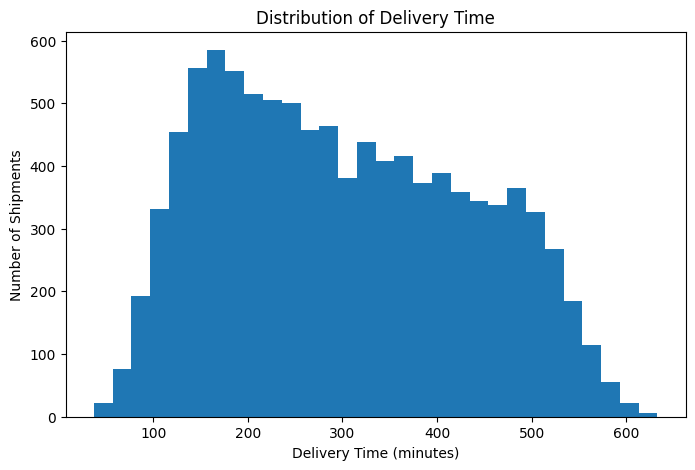

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["delivery_time_min"],
    bins=30
)

plt.title(
    "Distribution of Delivery Time"
)

plt.xlabel(
    "Delivery Time (minutes)"
)

plt.ylabel(
    "Number of Shipments"
)

plt.show()

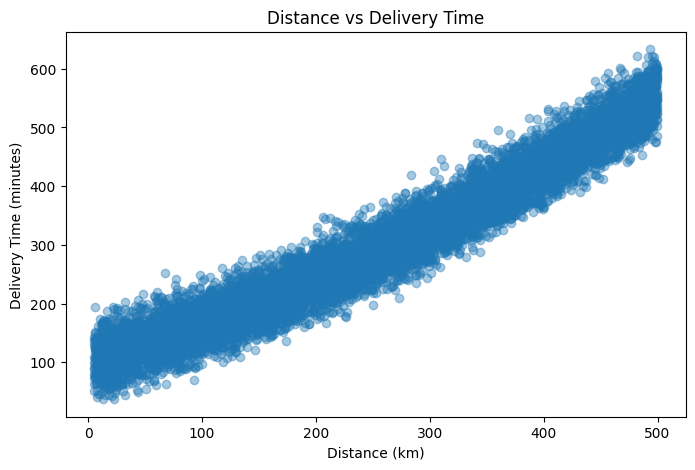

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["delivery_time_min"],
    alpha=0.4
)

plt.title(
    "Distance vs Delivery Time"
)

plt.xlabel(
    "Distance (km)"
)

plt.ylabel(
    "Delivery Time (minutes)"
)

plt.show()

traffic_level
High      326.260097
Low       283.241248
Medium    302.762791
Name: delivery_time_min, dtype: float64


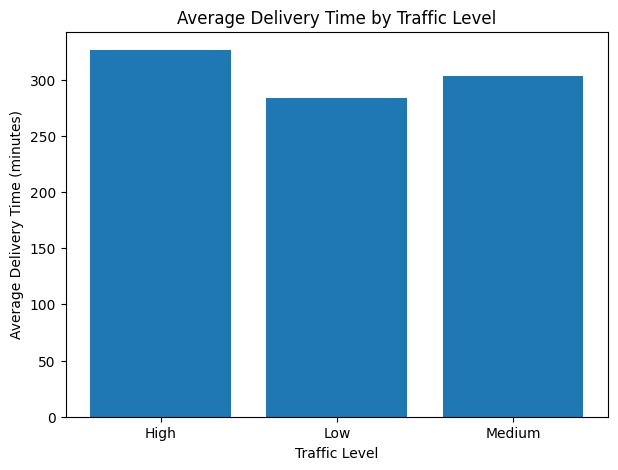

In [12]:
traffic_analysis = (
    df.groupby("traffic_level")
    ["delivery_time_min"]
    .mean()
)

print(
    traffic_analysis
)

plt.figure(figsize=(7, 5))

plt.bar(
    traffic_analysis.index,
    traffic_analysis.values
)

plt.title(
    "Average Delivery Time by Traffic Level"
)

plt.xlabel(
    "Traffic Level"
)

plt.ylabel(
    "Average Delivery Time (minutes)"
)

plt.show()

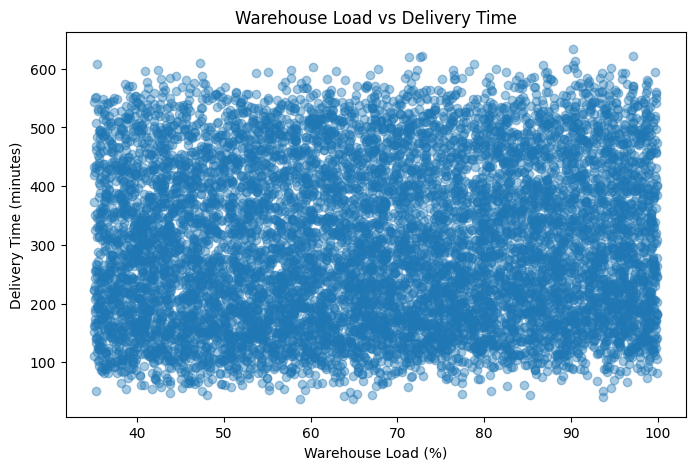

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["warehouse_load_pct"],
    df["delivery_time_min"],
    alpha=0.4
)

plt.title(
    "Warehouse Load vs Delivery Time"
)

plt.xlabel(
    "Warehouse Load (%)"
)

plt.ylabel(
    "Delivery Time (minutes)"
)

plt.show()

In [14]:
# Select numerical columns

numeric_df = df.select_dtypes(
    include=np.number
)

# Calculate correlation

correlation = numeric_df.corr()

print(correlation)

                         shipment_volume  distance_km  weather_delay_min  \
shipment_volume                 1.000000     0.000777           0.011440   
distance_km                     0.000777     1.000000          -0.006107   
weather_delay_min               0.011440    -0.006107           1.000000   
warehouse_load_pct              0.012651     0.007846           0.002547   
driver_experience_years         0.005347    -0.017001           0.003796   
vehicle_age_years               0.006132     0.005849           0.015878   
stops_count                     0.001166    -0.001540          -0.003387   
delivery_time_min               0.041756     0.969198           0.094689   

                         warehouse_load_pct  driver_experience_years  \
shipment_volume                    0.012651                 0.005347   
distance_km                        0.007846                -0.017001   
weather_delay_min                  0.002547                 0.003796   
warehouse_load_pct         

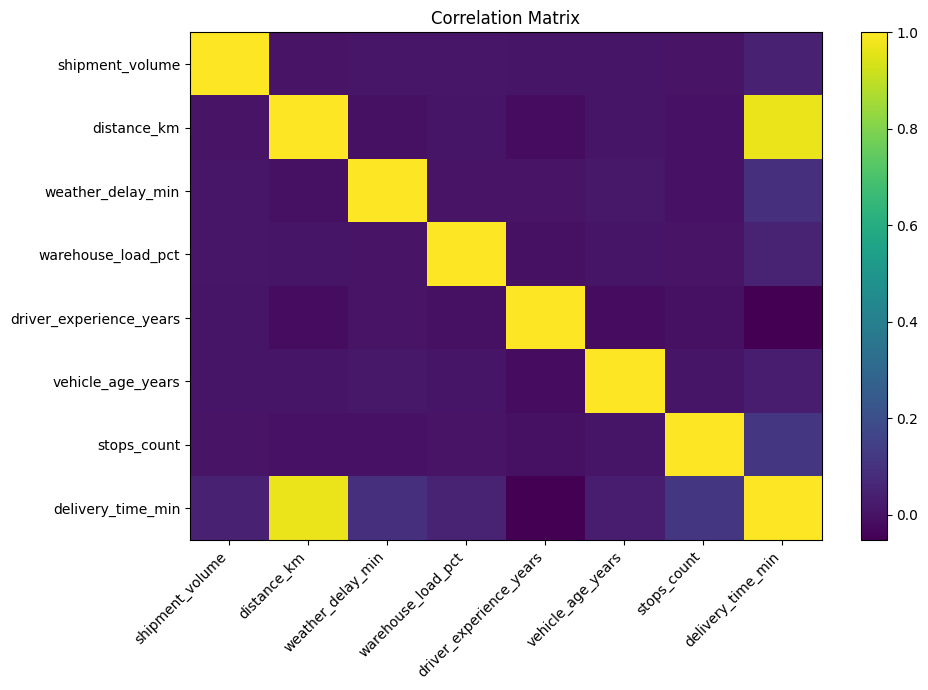

In [15]:
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.show()

In [16]:
# Define X and y

X = df.drop(
    columns=["delivery_time_min"]
)

y = df["delivery_time_min"]

print(
    "Features shape:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)

Features shape: (10000, 9)
Target shape: (10000,)


In [17]:
categorical_features = [
    "traffic_level",
    "order_priority"
]

numeric_features = [
    column
    for column in X.columns
    if column not in categorical_features
]

print(
    "Categorical features:"
)

print(
    categorical_features
)

print(
    "\nNumerical features:"
)

print(
    numeric_features
)

Categorical features:
['traffic_level', 'order_priority']

Numerical features:
['shipment_volume', 'distance_km', 'weather_delay_min', 'warehouse_load_pct', 'driver_experience_years', 'vehicle_age_years', 'stops_count']


In [18]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 8000
Testing samples: 2000


In [19]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print(
    "Preprocessing pipeline created!"
)

Preprocessing pipeline created!


In [20]:
# Linear Regression

linear_model = Pipeline(

    steps=[

        (
            "preprocess",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = (
    linear_model.predict(X_test)
)

print(
    "Linear Regression trained!"
)

Linear Regression trained!


In [21]:
# Random Forest Regression

random_forest_model = Pipeline(

    steps=[

        (
            "preprocess",
            preprocessor
        ),

        (
            "model",

            RandomForestRegressor(

                n_estimators=180,

                max_depth=14,

                min_samples_leaf=3,

                random_state=42,

                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = (
    random_forest_model.predict(X_test)
)

print(
    "Random Forest trained!"
)

Random Forest trained!


In [22]:
# Gradient Boosting Regression

gradient_model = Pipeline(

    steps=[

        (
            "preprocess",
            preprocessor
        ),

        (
            "model",

            GradientBoostingRegressor(

                n_estimators=180,

                learning_rate=0.06,

                max_depth=3,

                random_state=42
            )
        )
    ]
)

gradient_model.fit(
    X_train,
    y_train
)

gradient_predictions = (
    gradient_model.predict(X_test)
)

print(
    "Gradient Boosting trained!"
)

Gradient Boosting trained!


In [23]:
def evaluate_model(
    model_name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {

        "Model": model_name,

        "MAE (minutes)": mae,

        "RMSE (minutes)": rmse,

        "R2": r2
    }

In [24]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_predictions
    )
)

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "RMSE (minutes)"
)

results_df

,Model,MAE (minutes),RMSE (minutes),R2
2,Gradient Boosting,10.552051,13.261637,0.989749
1,Random Forest,12.369579,15.594555,0.985825
0,Linear Regression,14.295447,17.660248,0.981821


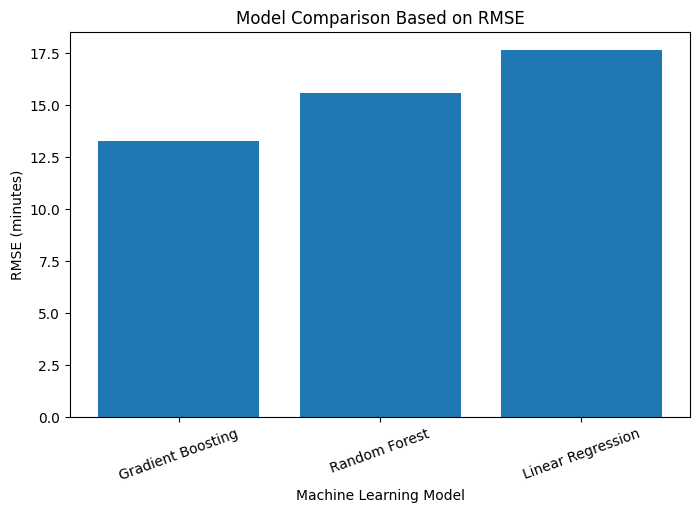

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE (minutes)"]
)

plt.title(
    "Model Comparison Based on RMSE"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "RMSE (minutes)"
)

plt.xticks(
    rotation=20
)

plt.show()

In [26]:
# Select model with lowest RMSE

best_model_name = (
    results_df
    .iloc[0]["Model"]
)

print(
    "Best Model:",
    best_model_name
)

Best Model: Gradient Boosting


In [27]:
# Five-fold cross-validation

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(

    gradient_model,

    X,

    y,

    cv=kf,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1
)

cv_rmse = -cv_scores

print(
    "Cross-validation RMSE:"
)

print(
    cv_rmse
)

print(
    "\nMean CV RMSE:",
    cv_rmse.mean()
)

print(
    "Standard deviation:",
    cv_rmse.std()
)

Cross-validation RMSE:
[13.26163662 13.14226329 13.5709537  13.63065707 13.63421273]

Mean CV RMSE: 13.44794468095392
Standard deviation: 0.20560283469721458


In [28]:
# Calculate permutation importance

importance = permutation_importance(

    gradient_model,

    X_test,

    y_test,

    n_repeats=5,

    random_state=42,

    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance": importance.importances_mean
})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False
)

importance_df

,Feature,Importance
1,distance_km,136.872039
8,stops_count,9.454156
3,traffic_level,8.638851
2,weather_delay_min,7.095342
4,warehouse_load_pct,1.373992
7,order_priority,1.114323
5,driver_experience_years,1.101144
0,shipment_volume,1.026992
6,vehicle_age_years,0.343613


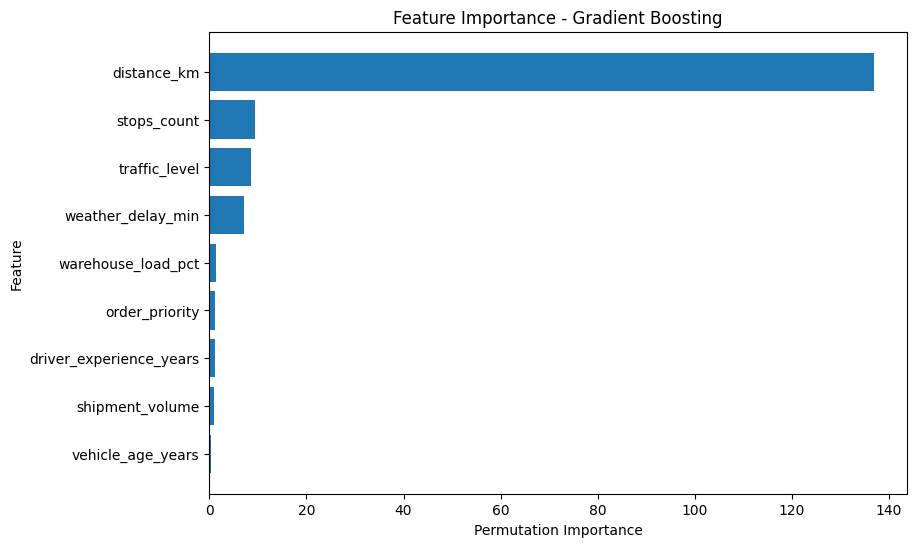

In [29]:
plt.figure(figsize=(9, 6))

plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]
)

plt.title(
    "Feature Importance - Gradient Boosting"
)

plt.xlabel(
    "Permutation Importance"
)

plt.ylabel(
    "Feature"
)

plt.gca().invert_yaxis()

plt.show()

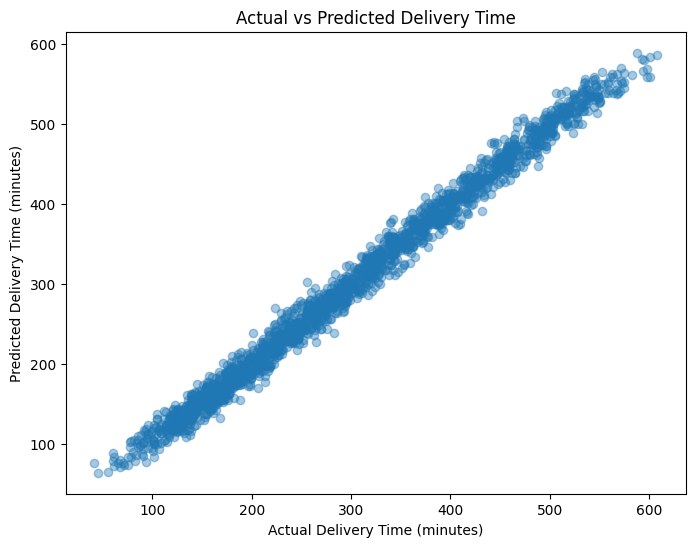

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(

    y_test,

    gradient_predictions,

    alpha=0.4
)

plt.xlabel(
    "Actual Delivery Time (minutes)"
)

plt.ylabel(
    "Predicted Delivery Time (minutes)"
)

plt.title(
    "Actual vs Predicted Delivery Time"
)

plt.show()

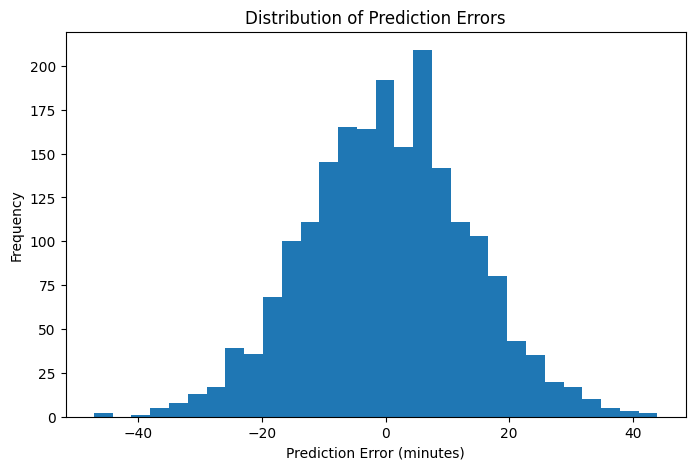

In [31]:
# Calculate residuals

residuals = (
    y_test -
    gradient_predictions
)

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30
)

plt.title(
    "Distribution of Prediction Errors"
)

plt.xlabel(
    "Prediction Error (minutes)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [32]:
# Hyperparameter tuning

param_grid = {

    "model__n_estimators": [
        100,
        150,
        200,
        300
    ],

    "model__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5
    ]
}

random_search = RandomizedSearchCV(

    gradient_model,

    param_distributions=param_grid,

    n_iter=10,

    cv=5,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:"
)

print(
    random_search.best_params_
)

print(
    "\nBest CV RMSE:"
)

print(
    -random_search.best_score_
)

Best Parameters:
{'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.1}

Best CV RMSE:
13.361517239048435


In [33]:
# Baseline logistics scenario

baseline = pd.DataFrame([{

    "shipment_volume": 300,

    "distance_km": 180,

    "weather_delay_min": 15,

    "traffic_level": "High",

    "warehouse_load_pct": 88,

    "driver_experience_years": 3,

    "vehicle_age_years": 6,

    "order_priority": "Standard",

    "stops_count": 12
}])

baseline

,shipment_volume,distance_km,weather_delay_min,traffic_level,warehouse_load_pct,driver_experience_years,vehicle_age_years,order_priority,stops_count
0,300,180,15,High,88,3,6,Standard,12


In [34]:
# Create optimized scenario

optimized = baseline.copy()

optimized["traffic_level"] = "Medium"

optimized["warehouse_load_pct"] = 70

optimized["driver_experience_years"] = 6

optimized["vehicle_age_years"] = 3

optimized["stops_count"] = 8

optimized["weather_delay_min"] = 8

optimized

,shipment_volume,distance_km,weather_delay_min,traffic_level,warehouse_load_pct,driver_experience_years,vehicle_age_years,order_priority,stops_count
0,300,180,8,Medium,70,6,3,Standard,8


In [35]:
# Predict baseline delivery time

baseline_time = gradient_model.predict(
    baseline
)[0]

# Predict optimized delivery time

optimized_time = gradient_model.predict(
    optimized
)[0]

# Calculate improvement

time_saved = (
    baseline_time -
    optimized_time
)

percentage_reduction = (
    time_saved /
    baseline_time
) * 100

print(
    f"Baseline Delivery Time: "
    f"{baseline_time:.2f} minutes"
)

print(
    f"Optimized Delivery Time: "
    f"{optimized_time:.2f} minutes"
)

print(
    f"Potential Time Saved: "
    f"{time_saved:.2f} minutes"
)

print(
    f"Potential Reduction: "
    f"{percentage_reduction:.2f}%"
)

Baseline Delivery Time: 264.98 minutes
Optimized Delivery Time: 222.11 minutes
Potential Time Saved: 42.87 minutes
Potential Reduction: 16.18%


## Logistics Optimization Strategies

Based on the predictive model, the following optimization strategies are proposed:

1. **Dynamic Route Planning**
   - Reduce unnecessary travel distance.
   - Consider traffic conditions when selecting routes.

2. **Warehouse Workload Balancing**
   - Avoid excessive warehouse utilization.
   - Distribute workload across available resources.

3. **Driver Assignment**
   - Assign experienced drivers to complex or time-sensitive routes.

4. **Stop Consolidation**
   - Reduce unnecessary delivery stops.
   - Group geographically close deliveries.

5. **Vehicle Maintenance**
   - Prioritize maintenance for older vehicles.
   - Replace inefficient vehicles when necessary.

6. **Weather and Traffic Buffers**
   - Adjust estimated delivery times according to predicted traffic and weather.

7. **Priority-Aware Dispatch**
   - Reserve capacity for express shipments.

In [36]:
# Save dataset as CSV

df.to_csv(
    "logistics_delivery_data.csv",
    index=False
)

print(
    "Dataset saved successfully!"
)

Dataset saved successfully!


In [37]:
from google.colab import files

files.download(
    "logistics_delivery_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
readme = """
# Week 4 - Predictive Modeling and Optimization in Logistics Systems

## Project Overview

This project applies predictive modeling and optimization techniques to a logistics delivery-time forecasting problem.

The objective is to predict delivery time based on operational, route, weather, warehouse, vehicle, and order-related factors.

## Dataset

A synthetic dataset containing 10,000 shipment records was generated using Python.

### Features

- shipment_volume
- distance_km
- weather_delay_min
- traffic_level
- warehouse_load_pct
- driver_experience_years
- vehicle_age_years
- order_priority
- stops_count

### Target

- delivery_time_min

## Machine Learning Models

Three regression models were evaluated:

1. Linear Regression
2. Random Forest Regression
3. Gradient Boosting Regression

## Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-squared (R2)

Five-fold cross-validation was also performed.

## Optimization Strategies

- Dynamic route planning
- Warehouse workload balancing
- Driver assignment
- Stop consolidation
- Vehicle maintenance
- Traffic-aware scheduling
- Weather-aware planning
- Priority-aware dispatch

## Technologies

- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Google Colab
- GitHub

## Project Workflow

Data Simulation
-> Data Exploration
-> Preprocessing
-> Train/Test Split
-> Model Training
-> Model Evaluation
-> Cross Validation
-> Feature Importance
-> Hyperparameter Tuning
-> Optimization Scenario
-> Recommendations

## Conclusion

The project demonstrates how predictive analytics can help logistics organizations forecast delivery times and make data-driven operational decisions.
"""

with open(
    "README.md",
    "w"
) as file:

    file.write(readme)

print(
    "README.md created successfully!"
)

README.md created successfully!


In [39]:
requirements = """
numpy
pandas
matplotlib
scikit-learn
"""

with open(
    "requirements.txt",
    "w"
) as file:

    file.write(
        requirements.strip()
    )

print(
    "requirements.txt created successfully!"
)

requirements.txt created successfully!


In [40]:
import os

print("Files created in Colab:")

for file in os.listdir():

    if file.endswith((
        ".csv",
        ".md",
        ".txt",
        ".ipynb"
    )):

        print(
            "✓",
            file
        )

Files created in Colab:
✓ requirements.txt
✓ logistics_delivery_data.csv
✓ README.md


In [41]:
from google.colab import files

files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>